In [ ]:
# Imports
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import timm
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Loading and unpacking data
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
# Defining path to the image folder
image_folder = 'dataset/dataset'

In [ ]:
# Counting the number of images
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
total_images = len(image_files)
print(f"Total images in folder: {total_images}")

Total images in folder: 9605


In [ ]:
# Visualizing several images after unpacking
def show_images(image_files, n):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        img_path = os.path.join(image_folder, image_files[i])
        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(image_files[i])
    plt.show()

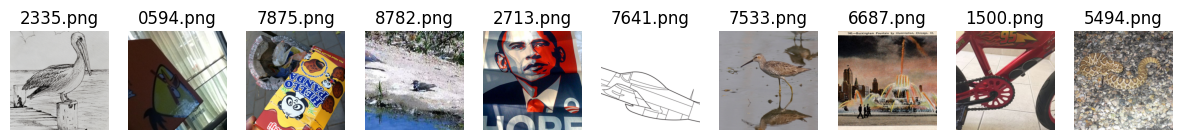

In [ ]:
# Displaying several images
show_images(image_files, n=10)


In [ ]:
# Dataset definition
class ImageDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.image_files = [f for f in os.listdir(image_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]


In [ ]:
# Defining transformations and data loader
transform = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_folder = 'dataset/dataset'
dataset = ImageDataset(image_folder, transform=transform)
data_loader = DataLoader(dataset, batch_size=16, shuffle=False)

In [ ]:
# Importing timm
import timm

# Getting list of all available models
available_models = timm.list_models()

# Filtering models containing "dino"
dino_models = [model for model in available_models if 'dino' in model]

print(dino_models)



['vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_giant_patch14_dinov2', 'vit_giant_patch14_reg4_dinov2', 'vit_large_patch14_dinov2', 'vit_large_patch14_reg4_dinov2', 'vit_small_patch14_dinov2', 'vit_small_patch14_reg4_dinov2']


In [ ]:
# Getting list of all available models
available_models_1 = timm.list_models()

# Filtering models containing "siglip"
siglip_models = [model for model in available_models_1 if 'siglip' in model]

print(siglip_models)


['vit_base_patch16_siglip_224', 'vit_base_patch16_siglip_256', 'vit_base_patch16_siglip_384', 'vit_base_patch16_siglip_512', 'vit_base_patch16_siglip_gap_224', 'vit_base_patch16_siglip_gap_256', 'vit_base_patch16_siglip_gap_384', 'vit_base_patch16_siglip_gap_512', 'vit_base_patch32_siglip_256', 'vit_base_patch32_siglip_gap_256', 'vit_giantopt_patch16_siglip_256', 'vit_giantopt_patch16_siglip_384', 'vit_giantopt_patch16_siglip_gap_256', 'vit_giantopt_patch16_siglip_gap_384', 'vit_large_patch16_siglip_256', 'vit_large_patch16_siglip_384', 'vit_large_patch16_siglip_512', 'vit_large_patch16_siglip_gap_256', 'vit_large_patch16_siglip_gap_384', 'vit_large_patch16_siglip_gap_512', 'vit_so400m_patch14_siglip_224', 'vit_so400m_patch14_siglip_378', 'vit_so400m_patch14_siglip_384', 'vit_so400m_patch14_siglip_gap_224', 'vit_so400m_patch14_siglip_gap_378', 'vit_so400m_patch14_siglip_gap_384', 'vit_so400m_patch14_siglip_gap_448', 'vit_so400m_patch14_siglip_gap_896', 'vit_so400m_patch16_siglip_256', 

In [ ]:
# Loading DINO v2 model

model = timm.create_model('vit_base_patch14_dinov2', pretrained=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
# Setting model to evaluation mode
model.eval()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Feature extraction
features_list = []
image_files = []

with torch.no_grad():
    for images, files in data_loader:
        images = images.to('cuda' if torch.cuda.is_available() else 'cpu')
        features = model(images)

        # Appending extracted features and filenames
        features_list.append(features.cpu().numpy())
        image_files.extend(files)
        print(f"Processed batch of {len(files)} images.")

# Checking that features_list is not empty
if features_list:
    features_matrix = np.concatenate(features_list)
else:
    raise ValueError("No features extracted.")

Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed batch of 16 images.
Processed 

In [ ]:
# Image comparison
similarity_matrix = cosine_similarity(features_matrix)

In [ ]:
# Generating results
results = []

for i, img_file in enumerate(image_files):
    similar_indices = np.argsort(similarity_matrix[i])[-7:-1]
    similar_files = [image_files[j] for j in similar_indices]
    results.append((img_file, ' '.join(similar_files)))

In [ ]:
# Saving to CSV
results_df = pd.DataFrame(results, columns=['filename', 'ranking'])
results_df.to_csv('submission.csv', index=False)

In [ ]:
# Visualizing one set of 6 most similar images
def show_similar_images(image_file, similar_files):
    plt.figure(figsize=(15, 5))

    # Displaying the original image
    original_img_path = os.path.join(image_folder, image_file)
    original_img = Image.open(original_img_path)
    plt.subplot(1, 7, 1)
    plt.imshow(original_img)
    plt.axis('off')
    plt.title("Original")

    # Displaying 6 similar images
    for i, similar_file in enumerate(similar_files):
        similar_img_path = os.path.join(image_folder, similar_file)
        similar_img = Image.open(similar_img_path)
        plt.subplot(1, 7, i + 2)
        plt.imshow(similar_img)
        plt.axis('off')
        plt.title(similar_file)

    plt.show()

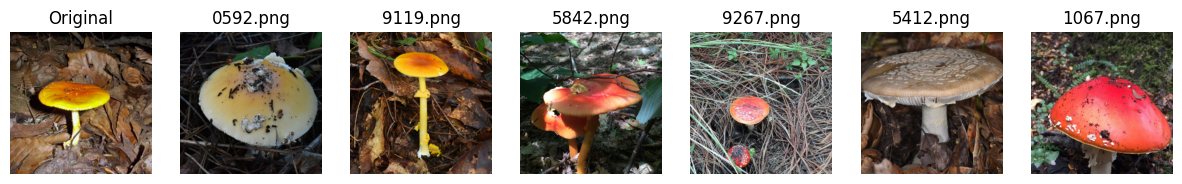

In [ ]:
# Visualization example for the first image
if results:
    first_image, similar_images = results[88]
    similar_images_list = similar_images.split()
    show_similar_images(first_image, similar_images_list)

Качество рекомендаций: 0.7132743362831858
test_model_accuracy (__main__.TestAccuracy.test_model_accuracy) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.000s

OK
 basic_score  5.0